In [5]:
import pandas as pd
df = pd.read_csv(r"cleaned_data.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Analyzing across several duets

### Rating vs Discount

Text(0, 0.5, 'Rating')

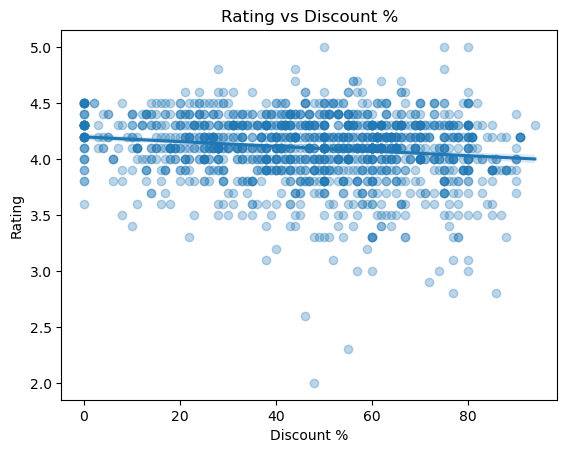

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(x="discount_percentage", y="rating", data=df, scatter_kws={'alpha':0.3})
plt.title('Rating vs Discount %')
plt.xlabel('Discount %')
plt.ylabel('Rating')

No strong visible correlation is observed between discount percentage and rating, suggesting discount has limited influence on customer satisfaction.

### Sale vs Discount

Text(0, 0.5, 'Sale')

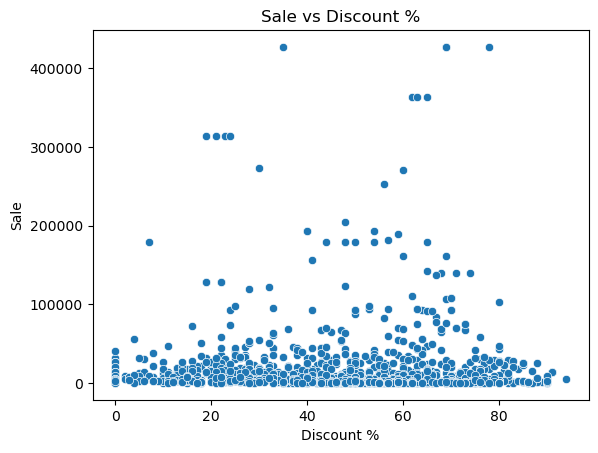

In [7]:
sns.scatterplot(x="discount_percentage", y="rating_count", data=df)
plt.title('Sale vs Discount %')
plt.xlabel('Discount %')
plt.ylabel('Sale')

As we know, the rating count is proxy to the number of sales, the amount of discount you provide, does not have any clear effect the sale of the products.

### Price vs Discount

Text(0, 0.5, 'Price')

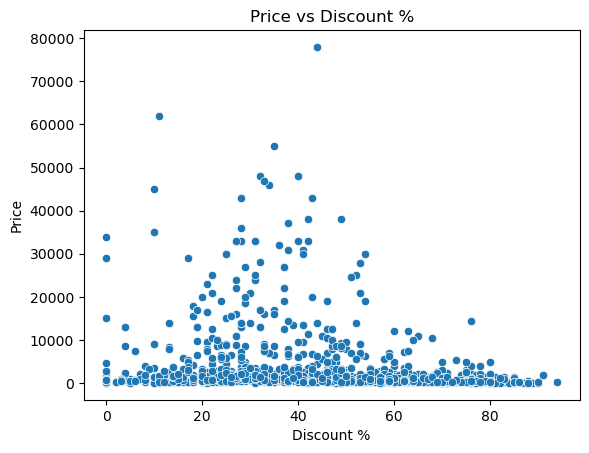

In [8]:
sns.scatterplot(x='discount_percentage', y='discounted_price', data=df)
plt.title('Price vs Discount %')
plt.xlabel('Discount %')
plt.ylabel('Price')

For High Price Products Discount % clusters around 40%. For Low Price Products Discount % varies highly from 0-100.

### Sale vs Price

Text(0, 0.5, 'Sale')

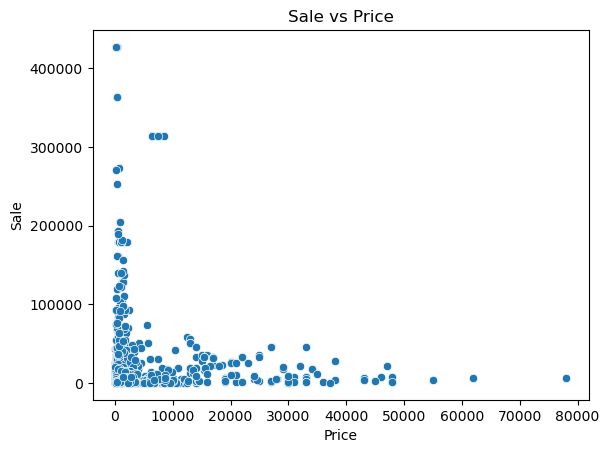

In [9]:
sns.scatterplot(x='discounted_price', y='rating_count', data=df)
plt.title('Sale vs Price')
plt.xlabel('Price')
plt.ylabel('Sale')

As expected, low price products sale is high (e.g. Daily necessities)

## Analyzing customer satisfaction along with Discount, Pricing and Category:

### Good Words: Positive review
### Bad Words: Negative review

In [10]:
good_words = ['good', 'great', 'excellent', 'amazing', 'best', 'nice', 'love']
bad_words = ['bad', 'worst', 'poor', 'waste', 'terrible', 'disappointed', 'low']
def count_keywords(text, keywords):
    text = str(text).lower()
    return sum(word in text for word in keywords)

df['good_count'] = df['review_content'].apply(lambda x: count_keywords(x, good_words))
df['bad_count'] = df['review_content'].apply(lambda x: count_keywords(x, bad_words))

<Figure size 800x500 with 0 Axes>

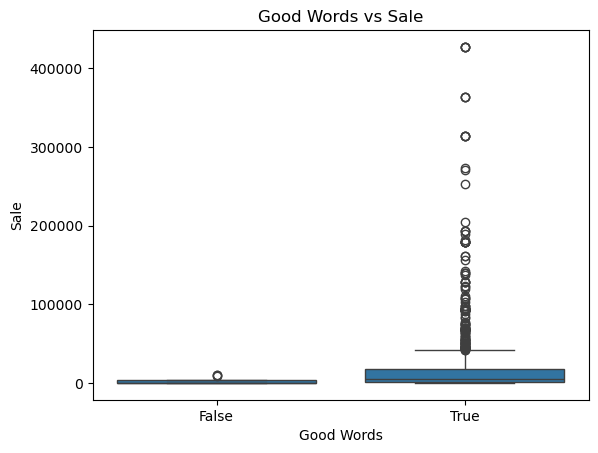

<Figure size 800x500 with 0 Axes>

In [11]:
sns.boxplot(x=(df['good_count'] > 0), y='rating_count', data=df)
plt.title('Good Words vs Sale')
plt.xlabel('Good Words')
plt.ylabel('Sale')
plt.figure(figsize=(8,5))

Products associated with positive sentiment (“Good Words”) show significantly higher sales and greater variability. In contrast, products without such sentiment have consistently low sales, indicating a strong relationship between positive language and product performance.

<Figure size 800x500 with 0 Axes>

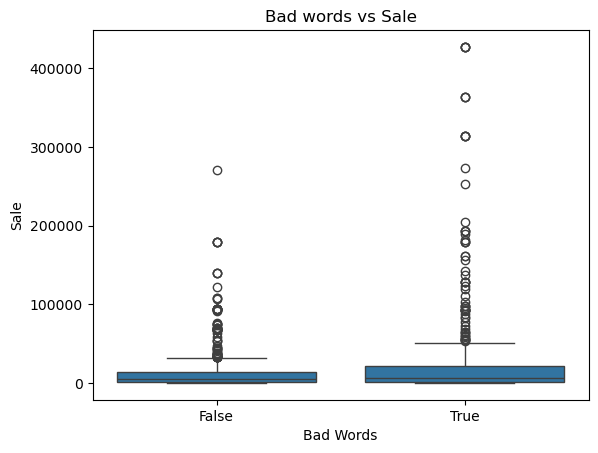

<Figure size 800x500 with 0 Axes>

In [12]:
sns.boxplot(x=(df['bad_count'] > 0), y='rating_count', data=df)
plt.title("Bad words vs Sale")
plt.xlabel('Bad Words')
plt.ylabel('Sale')
plt.figure(figsize=(8,5))

Products containing negative sentiment (“Bad Words”) still show strong sales performance with high variability. This suggests that high-selling products often receive mixed reviews rather than purely negative impact on sales.

<Figure size 800x500 with 0 Axes>

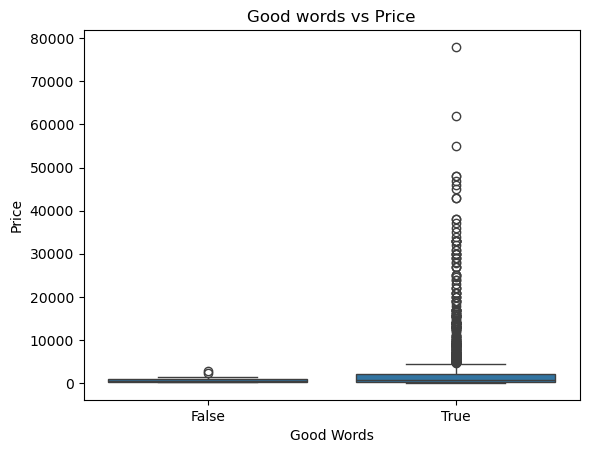

<Figure size 800x500 with 0 Axes>

In [13]:
sns.boxplot(x=(df['good_count'] > 0), y='discounted_price', data=df)
plt.title("Good words vs Price")
plt.xlabel('Good Words')
plt.ylabel('Price')
plt.figure(figsize=(8,5))

Good review product prices vary highly. The median at the bottom meaning most low price products are sold and reviewed more.

<Figure size 800x500 with 0 Axes>

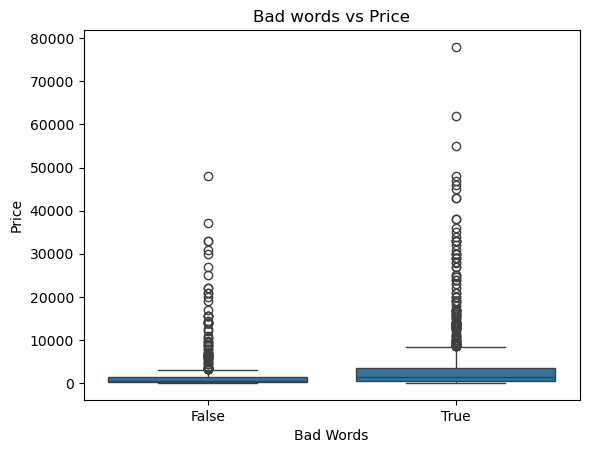

<Figure size 800x500 with 0 Axes>

In [14]:
sns.boxplot(x=(df['bad_count'] > 0), y='discounted_price', data=df)
plt.title("Bad words vs Price")
plt.xlabel('Bad Words')
plt.ylabel('Price')
plt.figure(figsize=(8,5))

Price varying for bad review products. Prices of Products without bad reviews also vary highly. No notable dependency of review upon the pricing of Products seen.

In [15]:
df['has_good'] = df['good_count'] > 0
df['has_bad'] = df['bad_count'] > 0

In [16]:
df.groupby('has_good')[['rating_count', 'discounted_price']].mean()

,rating_count,discounted_price
has_good,,
False,2603.500000,850.928571
True,18459.209945,3147.978228


Products with positive keywords like “good” tend to have significantly higher engagement (rating_count) and are generally priced higher, indicating a relationship between perceived quality, popularity, and pricing.

In [17]:
df.groupby('has_bad')[['rating_count', 'discounted_price']].mean()

,rating_count,discounted_price
has_bad,,
False,13288.654714,1801.749536
True,23637.557123,4536.192567


Products with higher engagement (rating_count) tend to contain both positive (“good”) and negative (“bad”) keywords in reviews. This suggests that highly popular and higher-priced products receive more diverse feedback due to increased customer interaction and expectations.

<Figure size 800x500 with 0 Axes>

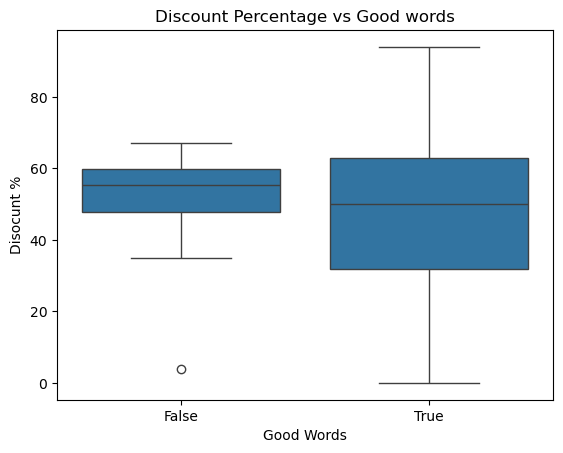

<Figure size 800x500 with 0 Axes>

In [18]:
sns.boxplot(x=(df['good_count'] > 0), y='discount_percentage', data=df)
plt.title("Discount Percentage vs Good words")
plt.xlabel('Good Words')
plt.ylabel('Disocunt %')
plt.figure(figsize=(8,5))

There is no clear relation between the disocunt percentage and customer satisfaction. Customers reviewing good for a range of discount percentage 30-60% while even 50-60% discounted products are getting neutral/bad reviews. This refers the company may be providing more discount on potential bad products so that they are sold fast.

<Figure size 800x500 with 0 Axes>

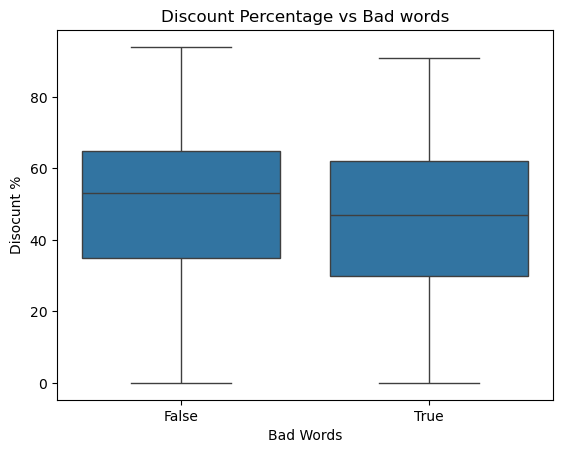

<Figure size 800x500 with 0 Axes>

In [19]:
sns.boxplot(x=(df['bad_count'] > 0), y='discount_percentage', data=df)
plt.title("Discount Percentage vs Bad words")
plt.xlabel('Bad Words')
plt.ylabel('Disocunt %')
plt.figure(figsize=(8,5))

The discount % ranges almost same whether the product has bad reviews or not. This potentially refers to the fact that discount percentage had very obscure on customer satisfaction for the company.

### Analyzing Review and Categorical relations

In [20]:
df['category_short'] = df['category'].str.split('|').str[0]
top_categories = df.groupby('category_short')['rating_count'].sum().sort_values(ascending=False).head(10).index
df_top = df[df['category_short'].isin(top_categories)]
summary = df_top.groupby('category_short').agg({
    'rating_count':'mean',
    'has_good':'mean',
    'has_bad':'mean'
})

summary[['has_good','has_bad']] *= 100
summary

,rating_count,has_good,has_bad
category_short,,,
Car&Motorbike,1118.000000,100.000000,0.000000
Computers&Accessories,17136.782705,99.558499,38.852097
Electronics,29997.809886,99.239544,59.315589
Health&PersonalCare,3663.000000,0.000000,100.000000
Home&Kitchen,6689.210291,98.434004,46.085011
HomeImprovement,4283.000000,100.000000,50.000000
MusicalInstruments,44441.000000,100.000000,100.000000
OfficeProducts,4828.225806,100.000000,35.483871
Toys&Games,15867.000000,100.000000,0.000000


Highly popular and complex electronic products such as headphones, smartphones, and smart TVs show significantly higher negative sentiment, likely due to higher user expectations and product complexity. In contrast, simpler and more standardized products like cables and memory cards exhibit lower complaint rates, indicating higher reliability and consistent performance.

<Figure size 800x500 with 0 Axes>

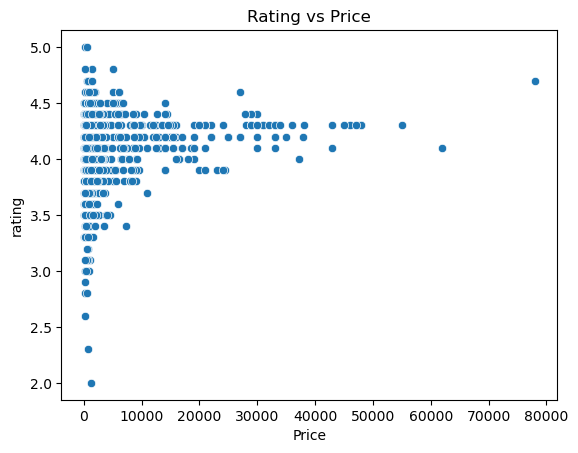

<Figure size 800x500 with 0 Axes>

In [21]:
sns.scatterplot(x='discounted_price', y='rating', data=df)
plt.title("Rating vs Price")
plt.xlabel('Price')
plt.ylabel('rating')
plt.figure(figsize=(8,5))

Low price products come up with ranging rating from 2-5 whereas high price products are more stable as their ratings converge to above 4.0 which means that the high-price products of the company tend to be very good in quality.

## Category-wise Average Rating

In [25]:
cat_rating = df.groupby('category_short')['rating'].mean().sort_values(ascending=False)
cat_rating.head(10)

category_short
OfficeProducts           4.309677
Toys&Games               4.300000
HomeImprovement          4.250000
Computers&Accessories    4.154967
Electronics              4.081749
Home&Kitchen             4.040716
Health&PersonalCare      4.000000
MusicalInstruments       3.900000
Car&Motorbike            3.800000
Name: rating, dtype: float64

The company sells the best Office Products, Toys and games as they prove with their highest rating values.

In [24]:
price_bins = pd.qcut(df['discounted_price'], 4)

df.groupby(price_bins, observed=True).agg({
    'rating':'mean',
    'rating_count':'mean',
    'discount_percentage':'mean'
})

,rating,rating_count,discount_percentage
discounted_price,,,
"(38.999, 323.75]",4.064754,16391.434066,55.797814
"(323.75, 799.0]",4.097587,21489.509383,51.525469
"(799.0, 1999.0]",4.087088,19610.571429,45.986264
"(1999.0, 77990.0]",4.137396,15637.307479,37.318560


The company providing less discount on high price products. Though all category prodcust come up with almost same average rating, the high-price options work perform better. The company sells the most products which price ranges from 323.75 to 799.0. No explicit advice to give for the performance enhancement.

## Summary

1. Discount percentage shows weak relationship with rating, indicating customer satisfaction is not driven by discounts.
2. Discount percentage also has poor effect on product sale quantity.
3. Lower-priced products tend to receive higher engagement (rating_count), suggesting higher sales volume.
4. Category plays a significant role in both rating and popularity, with certain categories consistently outperforming others.
5. Some products with lower ratings still show high rating counts, indicating that highly sold products can have varying levels of customer satisfaction.

Pricing and discount strategies primarily influence product visibility and engagement, while customer satisfaction (ratings) appears to be driven more by product quality and category-specific factors.